**PERÍODO ACADÉMICO:** 2026-A  
**ASIGNATURA:** ICCD412 Métodos Numéricos  
**GRUPO:** GR2  
**TIPO DE INSTRUMENTO:** AVANCE PROYECTO
**FECHA DE ENTREGA LÍMITE:** 21/06/2026  
**ALUMNO:** Jose Pallares, Jhosua Saa, Erick Toapanta.


### Etapa 1: Tratamiento de Datos

En esta primera etapa, preparamos el entorno de trabajo aislando la ventana temporal estricta de interés (octubre 2019 - octubre 2024) y limpiando el ruido a nivel de sistema para garantizar cálculos numéricos estables en las fases posteriores.

**Los desafíos identificados son:**
* **Filtrado Temporal:** Se aísla el periodo post-pandemia utilizando máscaras booleanas para trabajar únicamente con los 5 años exactos de interés.
* **Aritmética de Punto Flotante:** Se aplica un redondeo estricto a 8 decimales en el precio de cierre para mitigar el riesgo de acumulación de errores de truncamiento y propagación al resolver matrices.
* **Variable Independiente:** Los modelos matemáticos operan sobre ejes continuos en los números reales, no sobre objetos de calendario. Se crea la variable $t$, donde cada unidad de incremento representa un día hábil de operación bursátil.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. TRATAMIENTO DE DATOS ---
archivo = 'NASDAQ100.csv' # Nombre del archivo

try:
    df_total = pd.read_csv(archivo)

    # Convertir la columna Date a formato fecha
    df_total['Date'] = pd.to_datetime(df_total['Date'])

    # FILTRADO (Oct 2019 - Oct 2024)
    fecha_inicio = pd.to_datetime('2019-10-01')
    fecha_fin = pd.to_datetime('2024-10-31')
    mascara = (df_total['Date'] >= fecha_inicio) & (df_total['Date'] <= fecha_fin)

    # Nos quedamos solo con los datos que cumplen la condición
    df_analisis = df_total.loc[mascara].sort_values('Date').reset_index(drop=True).copy()

    # Estandarización a 8 decimales por redondeo
    df_analisis['Close'] = df_analisis['Close'].round(8)

    # Creación de variable independiente t (días de operación)
    df_analisis['t'] = np.arange(len(df_analisis))

    print("--- ETAPA 1: TRATAMIENTO COMPLETADO ---")
    print(f"Rango de datos: {df_analisis['Date'].min().date()} a {df_analisis['Date'].max().date()}")
    print(f"Total de registros (n): {len(df_analisis)}")
    print(f"Precio Mínimo: {df_analisis['Close'].min():.2f} | Precio Máximo: {df_analisis['Close'].max():.2f}")

except Exception as e:
    print(f"Error al procesar los datos: {e}")

--- ETAPA 1: TRATAMIENTO COMPLETADO ---
Rango de datos: 2019-10-01 a 2024-10-25
Total de registros (n): 1340
Precio Mínimo: 24.29 | Precio Máximo: 75.24


### Etapa 2: Interpolación y Suavizado

En esta fase, reconstruimos la trayectoria del índice NASDAQ-100 mitigando las fluctuaciones de alta frecuencia (el "ruido" diario) para obtener una función continua que sea matemáticamente tratable sin perder la fidelidad de los datos reales.

**Interpretación Técnica:**
* **Fidelidad de los Datos:** A diferencia de un ajuste global, la curva generada en esta etapa intercepta exactamente cada registro de precio de cierre diario de la base de datos.
* **Continuidad y Suavidad:** Se implementan Splines Cúbicos en lugar de una interpolación polinómica tradicional para evitar las oscilaciones catastróficas en los extremos (Fenómeno de Runge). Esto garantiza que en cada nodo de unión, la primera y segunda derivada sean idénticas.
* **Vector Denso de Evaluación:** Se genera un espacio muestral de 1000 puntos para trazar una curva fluida que facilita la identificación visual de la inercia del mercado.

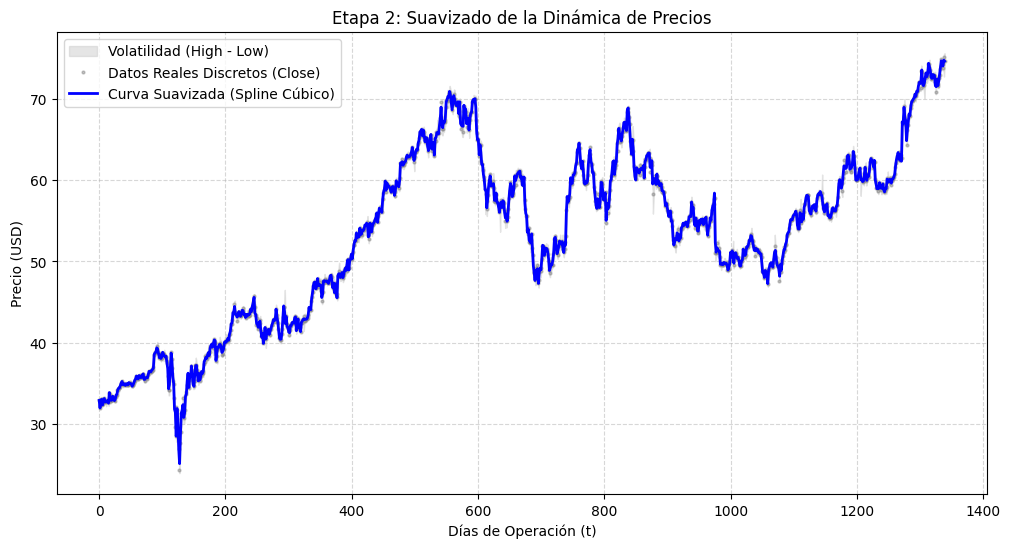

In [4]:
from scipy.interpolate import CubicSpline

# --- 2. INTERPOLACIÓN (SPLINES CÚBICOS) ---
t = df_analisis['t'].values
y = df_analisis['Close'].values

# Construcción de la función S(t) usando splines naturales
spline = CubicSpline(t, y, bc_type='natural')

# Se geera un vector de 1000 puntos para trazar la curva suave
t_suave = np.linspace(t.min(), t.max(), 1000)
y_spline = spline(t_suave)

plt.figure(figsize=(12, 6))

# Se dibuja el rango de volatilidad usando High y Low que vienen en el dataset
plt.fill_between(df_analisis['t'], df_analisis['Low'], df_analisis['High'], color='#cccccc', alpha=0.5, label='Volatilidad (High - Low)')
plt.plot(t, y, 'o', color='#888888', markersize=2, alpha=0.5, label='Datos Reales Discretos (Close)')
plt.plot(t_suave, y_spline, color='blue', linewidth=2, label='Curva Suavizada (Spline Cúbico)')

plt.title('Etapa 2: Suavizado de la Dinámica de Precios')
plt.xlabel('Días de Operación (t)')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()